# Mobilising needed libraries & 1st Checking of the datasets

In [101]:
# Core libraries
import pandas as pd
import numpy as np
import time
import warnings
import multiprocessing 
from datetime import date

# Use all but one CPU core for parallel processing
num_cores = multiprocessing.cpu_count() - 1
print("Using", num_cores, "cores for parallel processing.")

warnings.filterwarnings("ignore")

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical utilities
import scipy.stats as stats
from scipy.stats import chi2, chi2_contingency, f_oneway

# Statsmodels (ANOVA, OLS)
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Preprocessing & feature engineering
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

# Modelling algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Model evaluation & selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dimension reduction
from sklearn.decomposition import PCA

# Gradient boosting libraries
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost not available. Install it with: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("✓ LightGBM available")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠ LightGBM not available. Install it with: pip install lightgbm")

Using 13 cores for parallel processing.
✓ XGBoost available
✓ LightGBM available


In [102]:
# Importing the training dataset
train = pd.read_csv("ML_WP_data/train.csv")
# Checking the table
train.head()
# Calculate total number of NaN values in the DataFrame
total_train_nans = train.isna().sum().sum()

# Display the total count of NaN values
print("Total NaN values in the DataFrame:", total_train_nans)

Total NaN values in the DataFrame: 150


In [103]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7579 entries, 0 to 7578
Data columns (total 92 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   fkl010h0_ANT             7578 non-null   float64
 1   fkl010h0_BAS             7576 non-null   float64
 2   fkl010h0_DAV             7576 non-null   float64
 3   fkl010h0_DOL             7578 non-null   float64
 4   fkl010h0_GVE             7578 non-null   float64
 5   fkl010h0_INT             7576 non-null   float64
 6   fkl010h0_LUG             7579 non-null   float64
 7   fkl010h0_SIO             7576 non-null   float64
 8   fkl010h0_STG             7575 non-null   float64
 9   fkl010h0_ZER             7578 non-null   float64
 10  fkl010h3_ANT             7576 non-null   float64
 11  fkl010h3_BAS             7579 non-null   float64
 12  fkl010h3_DAV             7576 non-null   float64
 13  fkl010h3_DOL             7579 non-null   float64
 14  fkl010h3_GVE            

# Added Cyclical Encoding

In [104]:
def add_cyclical_features(df):
    """
    Add cyclical encodings and time-of-day / season indicators.
    - hour → hour_sin, hour_cos, is_night, is_morning, is_afternoon
    - season → season_sin, season_cos
    """
    df = df.copy()

    # 1) Encode hour (0–23) and create time-of-day flags
    if "hour" in df.columns and "hour_sin" not in df.columns:
        df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
        df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

        df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 6)).astype(int)
        df["is_morning"] = ((df["hour"] >= 6) & (df["hour"] <= 12)).astype(int)
        df["is_afternoon"] = ((df["hour"] >= 12) & (df["hour"] <= 18)).astype(int)

        df.drop(columns=["hour"], inplace=True)

    # 2) Encode season as cyclical (if present)
    if "season" in df.columns and "season_sin" not in df.columns:
        season_order = ["winter", "spring", "summer", "autumn"]
        season_to_num = {s: i for i, s in enumerate(season_order)}

        season_str = df["season"].astype(str).str.lower()
        df["season_num"] = season_str.map(season_to_num)

        df["season_sin"] = np.sin(2 * np.pi * df["season_num"] / 4)
        df["season_cos"] = np.cos(2 * np.pi * df["season_num"] / 4)

        df.drop(columns=["season", "season_num"], inplace=True)

    return df


# IMPROVED: Advanced Feature Engineering

# Exploratory Data Analysis

## Overview of Missing Values and Descriptive Statistics in the Dataset - CC

In [105]:
# Creating a summary DataFrame for variables with missing values
missing_summary = (
    pd.DataFrame({
        'Data_Type': train.dtypes,  # Get the data type of each column
        'Missing_Values': train.isnull().sum(),  # Calculate the total number of missing values in each column
        'Percent_Missing': (train.isnull().sum() / len(train) * 100).round(2)  # Calculate the percentage of missing values and round it to two decimal places
    })
    .query("Missing_Values > 0")  # Filter for columns that have missing values
    .sort_values(by='Missing_Values', ascending=False)  # Sort by the number of missing values, in descending order
)

# Generating a statistical summary of the dataset (similar to what .describe() provides)
summary_stats = train.describe(include='all').transpose()  # Transpose to have features as rows for easier viewing

# Merging the missing summary with descriptive statistics for better insights on the data
merged_summary = missing_summary.merge(
    summary_stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']],  # Select statistical measures to include
    left_index=True,  # Use the index of the missing summary
    right_index=True,  # Match it with the index of the summary statistics
    how='left'  # Perform a left join to keep all rows from missing summary
)

# Printing the merged summary, converting it to a string for better readability
print(merged_summary.to_string())

# Printing the total number of variables that have missing values
print(f"\nTotal variables with missing values: {len(missing_summary)}")

# Identifying all target columns, specifically the temperature variables to be predicted
target_columns = train.filter(like='target').columns.tolist()  # Filter columns that include 'target' in their names


                        Data_Type  Missing_Values  Percent_Missing         mean         std    min     25%     50%     75%     max
ure200h0_ANT              float64               4             0.05    75.620066   16.451426   15.5    64.1    79.6    89.4   100.0
ure200h0_DAV              float64               4             0.05    72.885373   18.614446   12.9    60.7    77.5   88.45    99.6
ure200h0_STG              float64               4             0.05    74.420568   17.349778   16.4    62.5    77.1    88.6   100.0
fkl010h0_STG              float64               4             0.05     2.062733    1.509565    0.0     1.0     1.7     2.7    12.1
tre200h0_BAS              float64               4             0.05    11.715525    7.885066  -12.7     5.6    11.4    17.4    35.9
tre200h0_lag24h           float64               4             0.05    10.012568    8.081936  -11.3     3.5     9.7   15.85    34.3
sre000h0_GVE              float64               4             0.05     13.33967   2

## Key observations of the Missing Value Summary and Dispersion Analysis



* **Precipitation (`rre150h0_*`)** – *rre150h0: Precipitation; hourly total*  
  * Most hourly values are zero (25%, 50%, 75% = 0).  
  * Maximum values up to 41.7 mm/hour (e.g., Lugano) are realistic for Swiss storms.  
  * Very small means and large standard deviations indicate strong right skew.  
  * These “outliers” are genuine rainfall events, not errors.

* **Global radiation (`gre000h0_*`)** – *gre000h0: Global radiation; hourly mean*  
  * Many zeros at night; daytime values reach up to around 1000 W/m².  
  * High standard deviation (~250 W/m²) reflects day–night cycles.  
  * Strongly skewed, possibly bimodal distribution (night vs. day).

* **Atmospheric pressure (`prestah0_*`)** – *prestah0: Atmospheric pressure at barometric altitude (QFE); hourly mean*  
  * Narrow ranges (~7 hPa std) consistent with expected altitudes.  
  * No missing or implausible values detected.  
  * Excellent sensor consistency across stations.

* **Temperature (`tre200h0_*`)** – *tre200h0: Temperature at 2 m above ground; hourly mean*  
  * Mean temperature varies by station (≈ 4 °C in Davos/Andermatt, ≈ 13 °C in Lugano).  
  * Ranges from −23 °C to +38 °C, plausible for Swiss seasonal extremes.  
  * Differences in means due to elevation, not data quality issues.

* **Humidity (`ure200h0_*`)** – *ure200h0: Relative air humidity 2 m above ground; hourly mean*  
  * Mostly within 0–100 %; rare minima (≈ 2–3 %) possible in very dry air.  
  * Some near-100 % readings are expected under saturated conditions.  
  * Physically bounded variable; clipping can be applied if needed.

* **Wind (`fkl010h*_*`)** – *fkl010h1: Gust peak (one second); hourly maximum in m/s*  
  * Substantial variability; some locations (La Dôle, Andermatt) show strong gusts.  
  * Distributions are right-skewed with high maxima but physically plausible.  
  * Reflects natural geographic differences rather than anomalies.

🎯 **Target columns in the dataset:**
- target_tre200h0_plus12h  
- target_tre200h0_plus24h  
- target_tre200h0_plus48h  

### Preprocessing recommendations

| Variable group                                       | Issues identified                    | Suggested action                                                |
| ---------------------------------------------------- | ------------------------------------ | --------------------------------------------------------------- |
| **Pressure**                                         | None                                 | Keep as is                                                      |
| **Temperature**                                      | Different baselines between stations | Apply Z-score normalisation per station                         |
| **Humidity**                                         | Physically bounded (0–100 %)         | Clip values to [0, 100]                                         |
| **Precipitation, Radiation, Wind**                   | Heavy right skew, many zeros         | Optionally apply log(1 + x) transformation before linear models |
| **Targets (`target_tre200h0_+12h`, `+24h`, `+48h`)** | No missing values                    | Keep as dependent variables                                     |

| Code  | Station    | Region    | Terrain type        |
|-------|-------------|-----------|---------------------|
| BAS   | Basel       | North     | Lowland             |
| GVE   | Genève      | West      | Lowland             |
| INT   | Interlaken  | Central   | Valley              |
| SIO   | Sion        | South     | Alpine valley       |
| STG   | St-Gallen   | Northeast | Foothills           |
| DAV   | Davos       | East      | High Alpine         |
| ZER   | Zermatt     | South     | High Alpine         |
| ANT   | Andermatt   | Central   | Mountain pass       |
| DOL   | La Dôle     | West      | Jura mountains      |
| LUG   | Lugano      | South     | Pre-Alpine / Ticino |

In [106]:
# Select only numeric columns
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()

# If you want to exclude targets, do it here:
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]
numeric_cols = [c for c in numeric_cols if c not in targets]

# Function to detect outliers using the IQR rule
def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    return outliers

# Apply to all numeric columns
outlier_summary = {}
for col in numeric_cols:
    n_outliers = len(detect_outliers(train, col))
    outlier_summary[col] = n_outliers

# Convert to DataFrame for easier analysis
outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=["Variable", "Outlier_Count"])
outlier_df["Outlier_%"] = (outlier_df["Outlier_Count"] / len(train)) * 100
outlier_df.sort_values(by="Outlier_%", ascending=False, inplace=True)

display(outlier_df.head(20))  # show top 20 variables with most outliers

,Variable,Outlier_Count,Outlier_%
60,sre000h0_INT,1783,23.525531
64,sre000h0_ZER,1782,23.512337
55,sre000h0_ANT,1752,23.116506
63,sre000h0_STG,1581,20.860272
56,sre000h0_BAS,1578,20.820689
57,sre000h0_DAV,1549,20.438053
59,sre000h0_GVE,1444,19.052645
58,sre000h0_DOL,1371,18.089458
48,rre150h0_DOL,1353,17.851959
45,rre150h0_ANT,1117,14.738092


Como vemos en la tabla, hay variables con gran porcentaje de observaciones consideradas extremas. Sin embargo, al comprobar la localización geográfica de esa observación, podemos concluir que más que valores extremos propios de un error de medición, estos valores se deben a la gran variabilidad geográfica y por ende meteorológica de Suiza.
En otras palabras, el IQR no toma en consideración el lugar en el que las mediciones fueron tomadas. Para referencia, hemos incluido una tabla con las localizaciones de las estaciones meteorológicas de esta base de datos.
En conclusión, no recomendamos eliminar los valores extremos, ya que, por ejemplo, una lluvia intensa en Davos, podría predecir una caída de temperaturas en Berna en las próximas 24h.

Winsorisation is not recommended either since the outliers are likely a real phenomenon and not measurement errors and winsorising would distort the weather distribution.

pair.plot de seaborn

# IMPROVED: Advanced Outlier Detection and Removal

In [107]:
def create_advanced_features(df, is_training=True):
    """
    Create advanced features for weather prediction.

    Parameters:
    -----------
    df : DataFrame
        Input dataframe
    is_training : bool
        Whether this is training data (affects which features we can create)

    Returns:
    --------
    DataFrame with new features
    """
    df = df.copy()

    # ============================================================
    # 1. CYCLICAL ENCODING (existing feature, keeping it)
    # ============================================================
    if 'hour' in df.columns:
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        # Create additional time features
        df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6)).astype(int)
        df['is_morning'] = ((df['hour'] >= 6) & (df['hour'] <= 12)).astype(int)
        df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] <= 18)).astype(int)
        df.drop(columns=['hour'], inplace=True)

    if 'season' in df.columns:
        season_order = ['winter', 'spring', 'summer', 'autumn']
        season_to_num = {s: i for i, s in enumerate(season_order)}
        df['season_num'] = df['season'].astype(str).str.lower().map(season_to_num)
        df['season_sin'] = np.sin(2 * np.pi * df['season_num'] / 4)
        df['season_cos'] = np.cos(2 * np.pi * df['season_num'] / 4)
        # Season indicators
        df['is_winter'] = (df['season_num'] == 0).astype(int)
        df['is_summer'] = (df['season_num'] == 2).astype(int)
        df.drop(columns=['season', 'season_num'], inplace=True)

    # ============================================================
    # 2. STATION AGGREGATIONS (Critical for weather patterns)
    # ============================================================
    # Temperature features (tre200h0)
    temp_cols = [c for c in df.columns if 'tre200h0_' in c and c != 'tre200h0' and 'lag' not in c]
    if len(temp_cols) > 0:
        df['temp_mean_all_stations'] = df[temp_cols].mean(axis=1)
        df['temp_std_all_stations'] = df[temp_cols].std(axis=1)
        df['temp_min_all_stations'] = df[temp_cols].min(axis=1)
        df['temp_max_all_stations'] = df[temp_cols].max(axis=1)
        df['temp_range_all_stations'] = df['temp_max_all_stations'] - df['temp_min_all_stations']

        # Current temperature deviation from mean
        if 'tre200h0' in df.columns:
            df['temp_current_vs_mean'] = df['tre200h0'] - df['temp_mean_all_stations']

        # If we have lag, create more features
        if 'tre200h0_lag24h' in df.columns and 'tre200h0' in df.columns:
            df['temp_change_24h'] = df['tre200h0'] - df['tre200h0_lag24h']
            df['temp_change_24h_abs'] = np.abs(df['temp_change_24h'])

    # Humidity features (ure200h0)
    humidity_cols = [c for c in df.columns if 'ure200h0_' in c]
    if len(humidity_cols) > 0:
        df['humidity_mean'] = df[humidity_cols].mean(axis=1)
        df['humidity_std'] = df[humidity_cols].std(axis=1)
        df['humidity_max'] = df[humidity_cols].max(axis=1)
        df['humidity_min'] = df[humidity_cols].min(axis=1)

    # Pressure features (prestah0)
    pressure_cols = [c for c in df.columns if 'prestah0_' in c]
    if len(pressure_cols) > 0:
        df['pressure_mean'] = df[pressure_cols].mean(axis=1)
        df['pressure_std'] = df[pressure_cols].std(axis=1)
        df['pressure_range'] = df[pressure_cols].max(axis=1) - df[pressure_cols].min(axis=1)

    # Wind features (fkl010h0, fkl010h3)
    wind_current_cols = [c for c in df.columns if 'fkl010h0_' in c]
    wind_3h_cols = [c for c in df.columns if 'fkl010h3_' in c]
    if len(wind_current_cols) > 0:
        df['wind_mean_current'] = df[wind_current_cols].mean(axis=1)
        df['wind_max_current'] = df[wind_current_cols].max(axis=1)
    if len(wind_3h_cols) > 0:
        df['wind_mean_3h'] = df[wind_3h_cols].mean(axis=1)
        df['wind_max_3h'] = df[wind_3h_cols].max(axis=1)
    if len(wind_current_cols) > 0 and len(wind_3h_cols) > 0:
        df['wind_change_3h'] = df['wind_mean_3h'] - df['wind_mean_current']

    # Precipitation features (rre150h0)
    precip_cols = [c for c in df.columns if 'rre150h0_' in c]
    if len(precip_cols) > 0:
        df['precip_total'] = df[precip_cols].sum(axis=1)
        df['precip_max'] = df[precip_cols].max(axis=1)
        df['precip_stations_active'] = (df[precip_cols] > 0).sum(axis=1)

    # Radiation features (gre000h0)
    radiation_cols = [c for c in df.columns if 'gre000h0_' in c]
    if len(radiation_cols) > 0:
        df['radiation_mean'] = df[radiation_cols].mean(axis=1)
        df['radiation_max'] = df[radiation_cols].max(axis=1)
        df['radiation_std'] = df[radiation_cols].std(axis=1)

    # ============================================================
    # 3. INTERACTION FEATURES (weather relationships)
    # ============================================================
    # Temperature * Humidity (feels-like temperature indicator)
    if 'temp_mean_all_stations' in df.columns and 'humidity_mean' in df.columns:
        df['temp_humidity_interaction'] = df['temp_mean_all_stations'] * df['humidity_mean']

    # Pressure * Wind (storm indicators)
    if 'pressure_mean' in df.columns and 'wind_mean_current' in df.columns:
        df['pressure_wind_interaction'] = df['pressure_mean'] * df['wind_mean_current']

    # Temperature * Radiation
    if 'temp_mean_all_stations' in df.columns and 'radiation_mean' in df.columns:
        df['temp_radiation_interaction'] = df['temp_mean_all_stations'] * df['radiation_mean']

    # ============================================================
    # 4. MISSING DATA FEATURES
    # ============================================================
    df['missing_count'] = df.isna().sum(axis=1)
    df['missing_temp_stations'] = df[temp_cols].isna().sum(axis=1) if len(temp_cols) > 0 else 0

    return df

## Visualizations of Target Variables: Distribution, Boxplot, and Q-Q Analysis

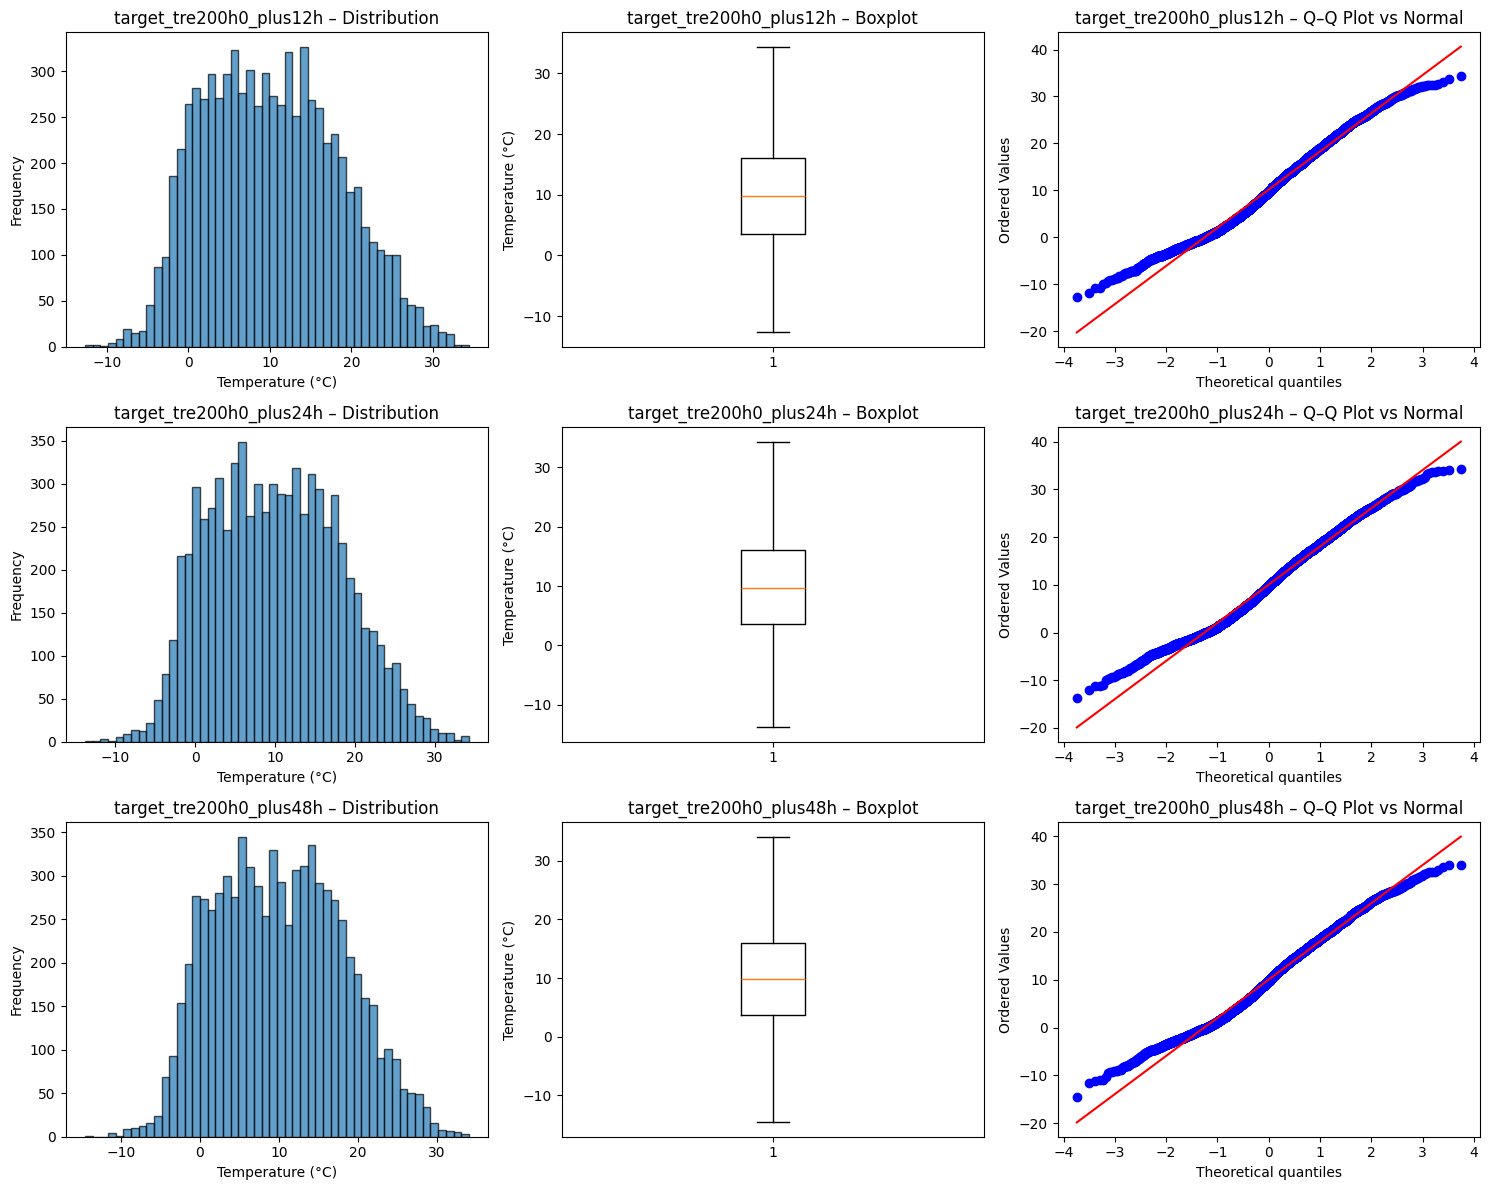

In [108]:
# List of target columns to visualize
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]

# Create subplots: each row corresponds to a target variable, with 3 columns for different plots
fig, axes = plt.subplots(len(targets), 3, figsize=(15, 12))

# Iterate through each target column to create visualizations
for i, target_col in enumerate(targets):
    # Histogram for the target variable's distribution
    axes[i, 0].hist(train[target_col], bins=50, edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f"{target_col} – Distribution")  # Title for the histogram
    axes[i, 0].set_xlabel("Temperature (°C)")  # Label for the x-axis
    axes[i, 0].set_ylabel("Frequency")  # Label for the y-axis

    # Boxplot for the target variable to visualize median and quartiles
    axes[i, 1].boxplot(train[target_col].dropna(), vert=True)  # Drop NaN values for the boxplot
    axes[i, 1].set_title(f"{target_col} – Boxplot")  # Title for the boxplot
    axes[i, 1].set_ylabel("Temperature (°C)")  # Label for the y-axis

    # Q-Q plot to assess normality of the target variable
    stats.probplot(train[target_col].dropna(), dist="norm", plot=axes[i, 2])  # Normal distribution comparison
    axes[i, 2].set_title(f"{target_col} – Q–Q Plot vs Normal")  # Title for the Q-Q plot

# Adjust layout to prevent overlap of subplots
plt.tight_layout()

# Show the combined plots
plt.show()


## Skewness and Kurtosis Analysis of Target Variables

In [109]:
# List of target columns to analyze for skewness and kurtosis
targets = ["target_tre200h0_plus12h", "target_tre200h0_plus24h", "target_tre200h0_plus48h"]

# Iterate through each target variable to compute skewness and kurtosis
for t in targets:
    clean_series = train[t].dropna()  # Remove missing values from the target series
    clean_series = clean_series[np.isfinite(clean_series)]  # Remove any infinite values (inf/-inf)

    # Calculate skewness to assess the asymmetry of the distribution
    skew = stats.skew(clean_series)
    
    # Calculate kurtosis to assess the "tailedness" of the distribution
    kurt = stats.kurtosis(clean_series)

    # Print the results in a formatted string
    print(f"{t}: Skewness = {skew:.3f}, Kurtosis = {kurt:.3f}")


target_tre200h0_plus12h: Skewness = 0.242, Kurtosis = -0.622
target_tre200h0_plus24h: Skewness = 0.199, Kurtosis = -0.624
target_tre200h0_plus48h: Skewness = 0.179, Kurtosis = -0.643


Los resultados que vimos en el histograma, boxplot y QQplot de arriba son confirmados por el análisis de skwenness. Al estar las tres variables objetivos con una skewness baja (sobre los 0.2 puntos), esto nos indica que hay ligreamente más temperaturas sobre cero que inferiores, cosa dentro de lo normal en mediciones de temperatura.
Respecto a la kurtosis, vemos como las tres variables tienen una ligera kurtosis negativa, indicando que las distribuciones son algo más planas y con colas más ligeras que una distribución normal.

## Analysis of Missing Values by Hour with Chi-Square Test

Top hours with most missing values:

hour
13.0    15
20.0    10
6.0      9
16.0     9
10.0     9
12.0     8
23.0     7
2.0      7
15.0     6
5.0      6
Name: missing_count, dtype: int64


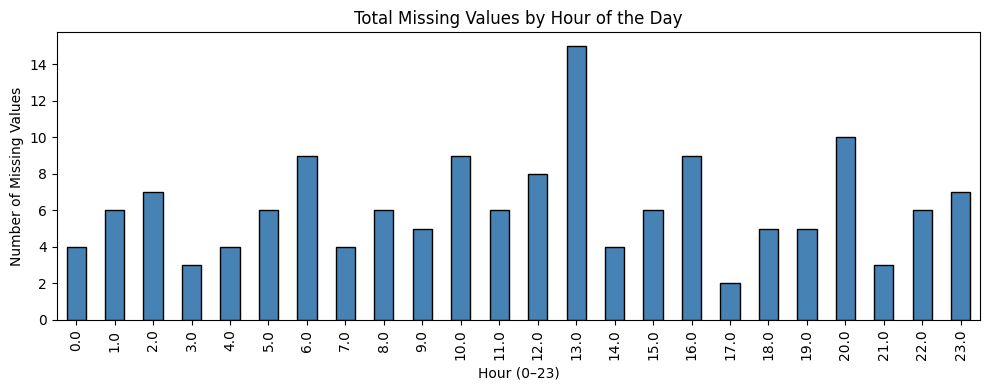

Chi-square statistic: 29.31
p-value: 0.1703
→ No significant hourly difference (fail to reject H₀).


In [110]:
# Calculate the count of missing values for each row in the train DataFrame
train['missing_count'] = train.isnull().sum(axis=1)

# Group the data by hour and compute the total missing values for each hour
missing_by_hour = (
    train.groupby('hour')['missing_count']
    .sum()  # Sum total missing values for each hour
    .sort_values(ascending=False)  # Sort hours by total missing values in descending order
)

# Display the top 10 hours with the most missing values
print("Top hours with most missing values:\n")
print(missing_by_hour.head(10))


# Plot the distribution of missing values by hour of the day
plt.figure(figsize=(10, 4))
missing_by_hour.sort_index().plot(kind='bar', color='steelblue', edgecolor='black')  # Bar plot
plt.title("Total Missing Values by Hour of the Day")  # Title of the plot
plt.xlabel("Hour (0–23)")  # X-axis label
plt.ylabel("Number of Missing Values")  # Y-axis label
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the plot

# Count total missing values per hour again for later analysis
missing_by_hour = train.groupby('hour')['missing_count'].sum()

# Chi-square goodness-of-fit test to assess if missing values differ by hour
# Null hypothesis: all hours have an equal count of missing values
expected = [missing_by_hour.sum() / len(missing_by_hour)] * len(missing_by_hour)  # Expected counts
chi2_stat = ((missing_by_hour - expected)**2 / expected).sum()  # Calculate chi-square statistic

# Calculate p-value from chi-square statistic
p_value = 1 - chi2.cdf(chi2_stat, df=len(missing_by_hour) - 1)

# Display chi-square statistic and p-value
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value:.4f}")

# Determine significance of the results
if p_value < 0.05:
    print("→ Missingness differs significantly by hour (reject H₀).")
else:
    print("→ No significant hourly difference (fail to reject H₀).")


Como vemos en el gráfico de barras de arriba, los valores ausentes parecen más o menos uniformemente distribuidos a través de las horas del día, con tan solo pequeñas fluctuaciones y un ligero pico a las 13h. En general, podríamos decir que no hay patrones horarios sistemáticos en la falta de observaciones. Esto es confirmado mediante el test de chi-cuadrado, con una p-value superior a 0.05, en otras palabras, no podemos rechazar la hipótesis nula de independencia entre hora y ausencia de observaciones. En conclusión, estos datos podrían ser descritos como Missing Completetly at Random (MCAR) respecto a la hora del día.

## Seasonal Analysis of Missing Values with Chi-Square and ANOVA Tests


Missing values by season:
season
Winter    28
Spring    34
Summer    47
Autumn    40
Name: missing_count, dtype: int64


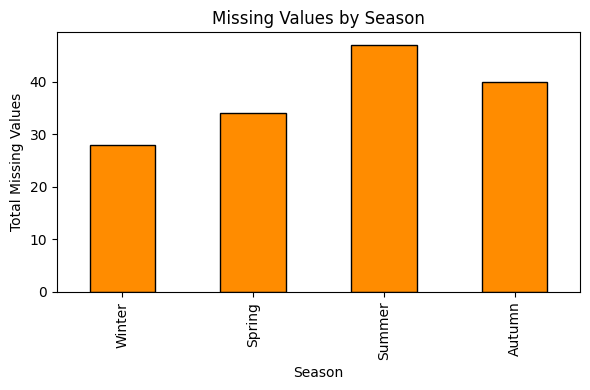

=== Chi-square Test for Seasonal Missingness ===
Chi-square statistic: 5.34
Degrees of freedom: 3
p-value: 0.1488
→ No significant seasonal difference in missingness (fail to reject H₀).

=== ANOVA Test for Seasonal Missingness ===
               sum_sq      df         F    PR(>F)
C(season)    0.118765     3.0  2.054394  0.104031
Residual   145.951570  7574.0       NaN       NaN


In [111]:
# --- Seasonal analysis of missing values (only if 'season' column exists) ---

# Check that the DataFrame actually contains a 'season' column
if 'season' in train.columns:
    # Define a logical order of the seasons for nicer plotting and reading
    season_order = ['Winter', 'Spring', 'Summer', 'Autumn']

    # Group the data by season and sum the total number of missing values per season
    # Then reindex the result so that the rows follow the desired season order
    missing_by_season = (
        train.groupby('season')['missing_count']
        .sum()  # Sum the total missing values for each season
        .reindex(season_order)  # Reindex to ensure the order of seasons
    )

    # Print the total missing values per season to the console
    print("\nMissing values by season:")
    print(missing_by_season)

    # Create a bar plot showing total missing values per season
    plt.figure(figsize=(6, 4))  # Set the figure size for the plot
    missing_by_season.plot(
        kind='bar',            # Create a bar chart
        color='darkorange',    # Set the bar colour
        edgecolor='black'      # Set the bar border colour
    )
    plt.title("Missing Values by Season")     # Add a title to the plot
    plt.xlabel("Season")                      # Label for the x-axis
    plt.ylabel("Total Missing Values")        # Label for the y-axis
    plt.tight_layout()                        # Adjust layout to avoid overlaps
    plt.show()                                # Display the plot

    # --- Chi-square test: Missing values by season ---

    # Recompute the grouped totals (no reindex needed, we just need counts)
    missing_by_season = train.groupby('season')['missing_count'].sum()

    # Under the null hypothesis, missingness is equally distributed across seasons.
    # Compute the expected count per season: total_missing / number_of_seasons.
    total_missing = missing_by_season.sum()              # Total number of missing values across all seasons
    n_seasons = len(missing_by_season)                   # Number of distinct seasons
    expected = [total_missing / n_seasons] * n_seasons   # Create a list of expected counts for each season

    # Compute the chi-square statistic manually:
    # sum( (observed - expected)^2 / expected ) for all seasons.
    chi2_stat = ((missing_by_season - expected) ** 2 / expected).sum()

    # Compute the p-value using the chi-square distribution CDF.
    # Degrees of freedom = number_of_seasons - 1.
    df = n_seasons - 1
    p_value = 1 - chi2.cdf(chi2_stat, df=df)  # Calculate the p-value

    # Print the results of the chi-square test
    print("=== Chi-square Test for Seasonal Missingness ===")
    print(f"Chi-square statistic: {chi2_stat:.2f}")  # Display chi-square statistic
    print(f"Degrees of freedom: {df}")                # Display degrees of freedom
    print(f"p-value: {p_value:.4f}")                  # Display p-value

    # Interpret the result at the 5% significance level
    if p_value < 0.05:
        print("→ Missingness differs significantly by season (reject H₀ of equal distribution).")
    else:
        print("→ No significant seasonal difference in missingness (fail to reject H₀).")

    # --- ANOVA: Does the mean missing_count differ by season? ---

    # Fit a linear model where 'missing_count' is explained by the categorical variable 'season'
    # C(season) tells statsmodels to treat 'season' as a categorical factor.
    model = ols('missing_count ~ C(season)', data=train).fit()

    # Perform an ANOVA (Type II sums of squares) on the fitted model
    anova_table = sm.stats.anova_lm(model, typ=2)

    # Print the ANOVA table to inspect whether season explains variance in missing_count
    print("\n=== ANOVA Test for Seasonal Missingness ===")
    print(anova_table)

else:
    # If 'season' is not present, inform the user and skip seasonal analysis
    print("Column 'season' not found in 'train': skipping seasonal missingness analysis.")


Como se observa en el gráfico anterior, los valores ausentes son más frecuentes en verano, con un total de 47, y en otoño, con 40. La ausencia de datos es independiente de la estación en la que se producen, ya que el test chi-cuadrado presenta un p-valor superior a 0.05; por tanto, no se rechaza la hipótesis nula $H_0$. En consecuencia, la ausencia de datos es aleatoria y despreciable, como muestran los números absolutos de valores faltantes. En otras palabras, estos valores ausentes representan ruido aleatorio.

A modo de conclusión, tanto los análisis por hora como por estación indican que las observaciones ausentes están distribuidas de manera aleatoria en el tiempo. Los test chi-cuadrado y ANOVA muestran que no existen diferencias estadísticamente significativas entre horas ni estaciones (p-valor superior a 0.05). Por ello, las observaciones ausentes son consistentes con un patrón de tipo Missing Completely at Random (MCAR). Esto justifica el uso de técnicas de imputación simple, ya que la ausencia de observaciones y su posterior imputación no introducirían sesgos en el entrenamiento de los modelos estadísticos.


# Data Preprocessing: Handling Missing Values and Creating Imputed Datasets

In [112]:
print("=== Training data preparation ===")

# 1. Start from raw training data
train_base = train.copy()
print("Raw train shape:", train_base.shape)

# 2. Add cyclical time features (your existing function)
print("\n[1/3] Applying cyclical encoding...")
train_cyc = add_cyclical_features(train_base)
print("After cyclical features:", train_cyc.shape)

# 3. Create advanced features (friend's version)
#    NOTE: this function already adds:
#      - 'missing_count'
#      - 'missing_temp_stations'
print("\n[2/3] Creating advanced features (friend's version)...")
train_enhanced = create_advanced_features(train_cyc, is_training=True)
print("After advanced features:", train_enhanced.shape)

# 4. Detect and remove outliers
print("\n[3/3] Detecting and removing outliers...")
train_clean = detect_and_remove_outliers(
    train_enhanced,
    method="both",      # z-score + IQR (adapt if you changed the function)
    threshold=3.5,
    iqr_multiplier=2.0
)

print("\n✅ Training data preparation complete.")
print("Final train_clean shape:", train_clean.shape)
print("Total remaining NAs in train_clean:", train_clean.isna().sum().sum())


=== Training data preparation ===
Raw train shape: (7579, 93)

[1/3] Applying cyclical encoding...
After cyclical features: (7579, 98)

[2/3] Creating advanced features (friend's version)...
After advanced features: (7579, 128)

[3/3] Detecting and removing outliers...
Detected 1580 outliers (20.85%)
DataFrame shape after outlier removal: (5999, 128)

✅ Training data preparation complete.
Final train_clean shape: (5999, 128)
Total remaining NAs in train_clean: 0


# testing the cyclical features

In [113]:
# --- Step 1: Preserve original and define base datasets ---

# Use the cleaned training data (cyclical + advanced features + outliers removed)
base = train_clean.copy()

# Identify numeric and categorical columns in the dataset
num_cols = base.select_dtypes(include='number').columns  # Numeric columns
cat_cols = base.select_dtypes(exclude='number').columns  # Categorical columns

# 1) Drop rows with any NA values
train_drop = base.dropna()

# 2) Mean-imputed dataset
mean_imputer = SimpleImputer(strategy='mean')
train_mean_imp = base.copy()
train_mean_imp[num_cols] = mean_imputer.fit_transform(train_mean_imp[num_cols])

# Fill missing values in categorical columns with the mode, if applicable
if len(cat_cols) > 0:
    cat_modes_mean = train_mean_imp[cat_cols].mode().iloc[0]
    train_mean_imp[cat_cols] = train_mean_imp[cat_cols].fillna(cat_modes_mean)

# 3) Median-imputed dataset
median_imputer = SimpleImputer(strategy='median')
train_median_imp = base.copy()
train_median_imp[num_cols] = median_imputer.fit_transform(train_median_imp[num_cols])

if len(cat_cols) > 0:
    cat_modes_median = train_median_imp[cat_cols].mode().iloc[0]
    train_median_imp[cat_cols] = train_median_imp[cat_cols].fillna(cat_modes_median)

# 4) KNN imputation (more sophisticated)
print("\nPerforming KNN imputation (this may take a moment)...")
train_knn_imp = base.copy()

knn_numeric_cols = train_knn_imp.select_dtypes(include=[np.number]).columns
knn_numeric_data = train_knn_imp[knn_numeric_cols]

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
train_knn_imp[knn_numeric_cols] = knn_imputer.fit_transform(knn_numeric_data)

# Optional: fill categorical missing values in KNN dataset with modes
if len(cat_cols) > 0:
    cat_modes_knn = train_knn_imp[cat_cols].mode().iloc[0]
    train_knn_imp[cat_cols] = train_knn_imp[cat_cols].fillna(cat_modes_knn)

print(f"knn_imputed shape: {train_knn_imp.shape}")
print("\nAll dataset variants created successfully!")

# Sanity checks
print(f"Rows before drop: {len(base)}, after drop: {len(train_drop)}")
print("Remaining NAs after drop:", train_drop.isnull().sum().sum())
print("Remaining NAs after mean imputation:", train_mean_imp.isnull().sum().sum())
print("Remaining NAs after median imputation:", train_median_imp.isnull().sum().sum())
print("Remaining NAs after KNN imputation:", train_knn_imp.isnull().sum().sum())

# --- Step 2: Build datasets dictionary (NO scaling, NO PCA) ---
datasets = {
    'drop_na':        train_drop,
    'mean_imputed':   train_mean_imp,
    'median_imputed': train_median_imp,
    'knn_imputed':    train_knn_imp
}

# Quick sanity check on cyclical features
datasets['drop_na'][['hour_sin', 'hour_cos']].head()



Performing KNN imputation (this may take a moment)...
knn_imputed shape: (5999, 128)

All dataset variants created successfully!
Rows before drop: 5999, after drop: 5999
Remaining NAs after drop: 0
Remaining NAs after mean imputation: 0
Remaining NAs after median imputation: 0
Remaining NAs after KNN imputation: 0


,hour_sin,hour_cos
0,0.965926,0.258819
1,0.707107,0.707107
2,0.000000,1.000000
3,-0.258819,-0.965926
4,0.258819,-0.965926


## Correlation Matrix Visualization for Numeric Variables

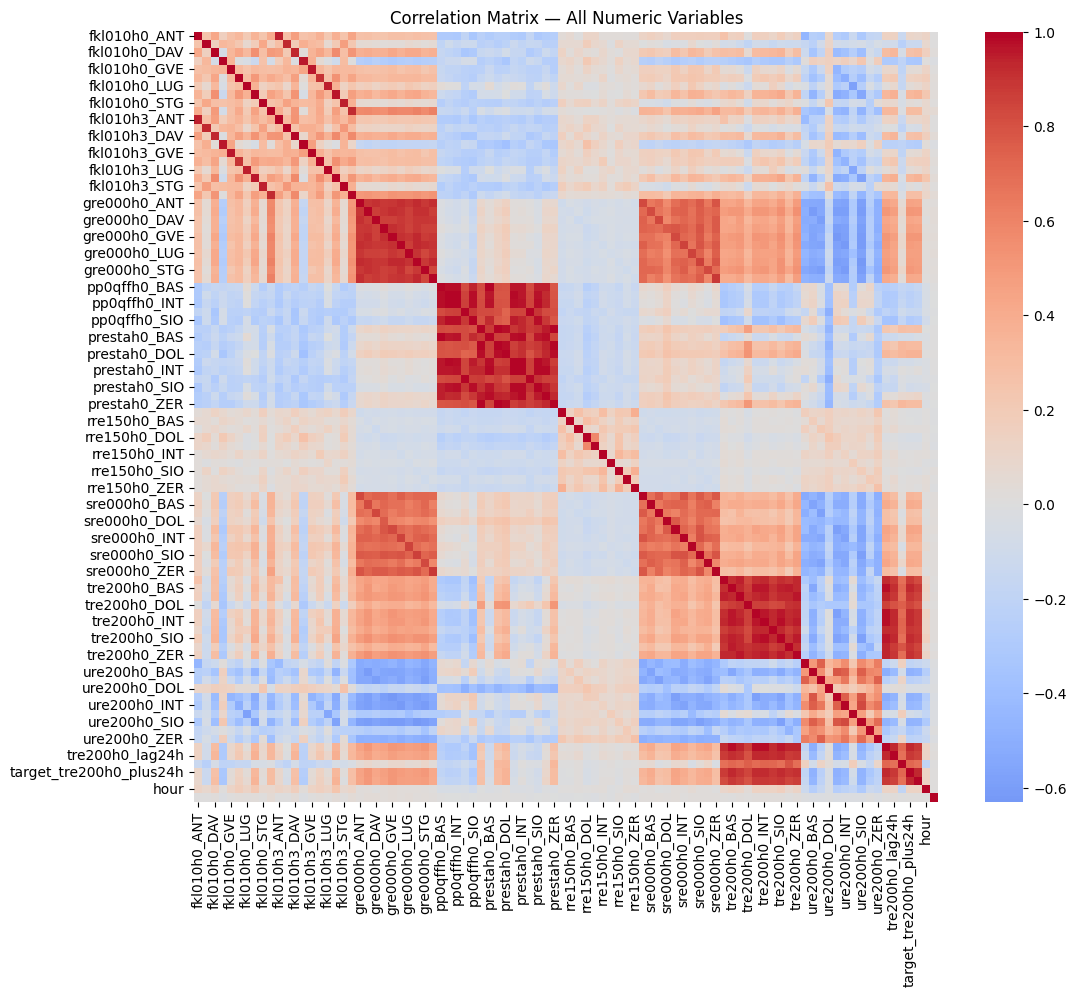

In [114]:
# Compute the correlation matrix for all numeric variables in the training dataset
corr = train.corr(numeric_only=True)  # Use numeric_only=True to include only numeric columns in the correlation calculation

# Set up the figure for displaying the heatmap
plt.figure(figsize=(12, 10))  # Specify the size of the figure

# Create a heatmap to visualize the correlation matrix
sns.heatmap(corr, cmap="coolwarm", center=0)  # Use "coolwarm" color palette to represent correlation values

# Add a title to the heatmap for clarity
plt.title("Correlation Matrix — All Numeric Variables")

# Display the heatmap
plt.show()


El el gráfico de correlaciones arriba, vemos como hay una gran correlación intravariable en cada estación meteorológica como en la variable gre000h0 (que mide la radiación) o en prestah0 (que mide la presión atmosférica). Esto no es anómalo, puesto que las estaciones meteorológicas son espacialmente coherentes, en otras palabras, las temperaturas y presiones atmosféricas se mueven de manera armoniosa. Del mismo modo, hay correlaciones cruzadas débiles entre variables. Por ejemplo, la variable tre200h0 (temperatura) está correlacionada positivamente con gre000h0 (radiación) y negativamente con ure200h0 (humedad). De igual modo, rre150h0(precipitaciones) está correlacionada negativamente con gre000h0 (radiación), lo que nos indica consistencia en términos meteorológicos (los valores de las variables están dentro de los rangos esperados para Suiza)

Sin embargo, la alta correlación entre variables implica multicolinealidad, es decir, la presencia de información redundante entre predictores que puede distorsionar el ajuste de ciertos modelos. Esta multicolinearidad no afecta a la capacidad predictiva de nuestros modelos, pero si podría inflar la varianza de los coeficientes y desestabilizar los modelos lineales o de regresión. Para neutralizar este impacto negativo, se podrían aplicar un Principal Analysis Components (PCA) con la cuál reduciríamos la dimensionalidad de los datos. También se podrían eliminar las variables altamente correlacionadas, evitando así redundancias.

# Visualizing Correlation with Target Variable in DataFrame

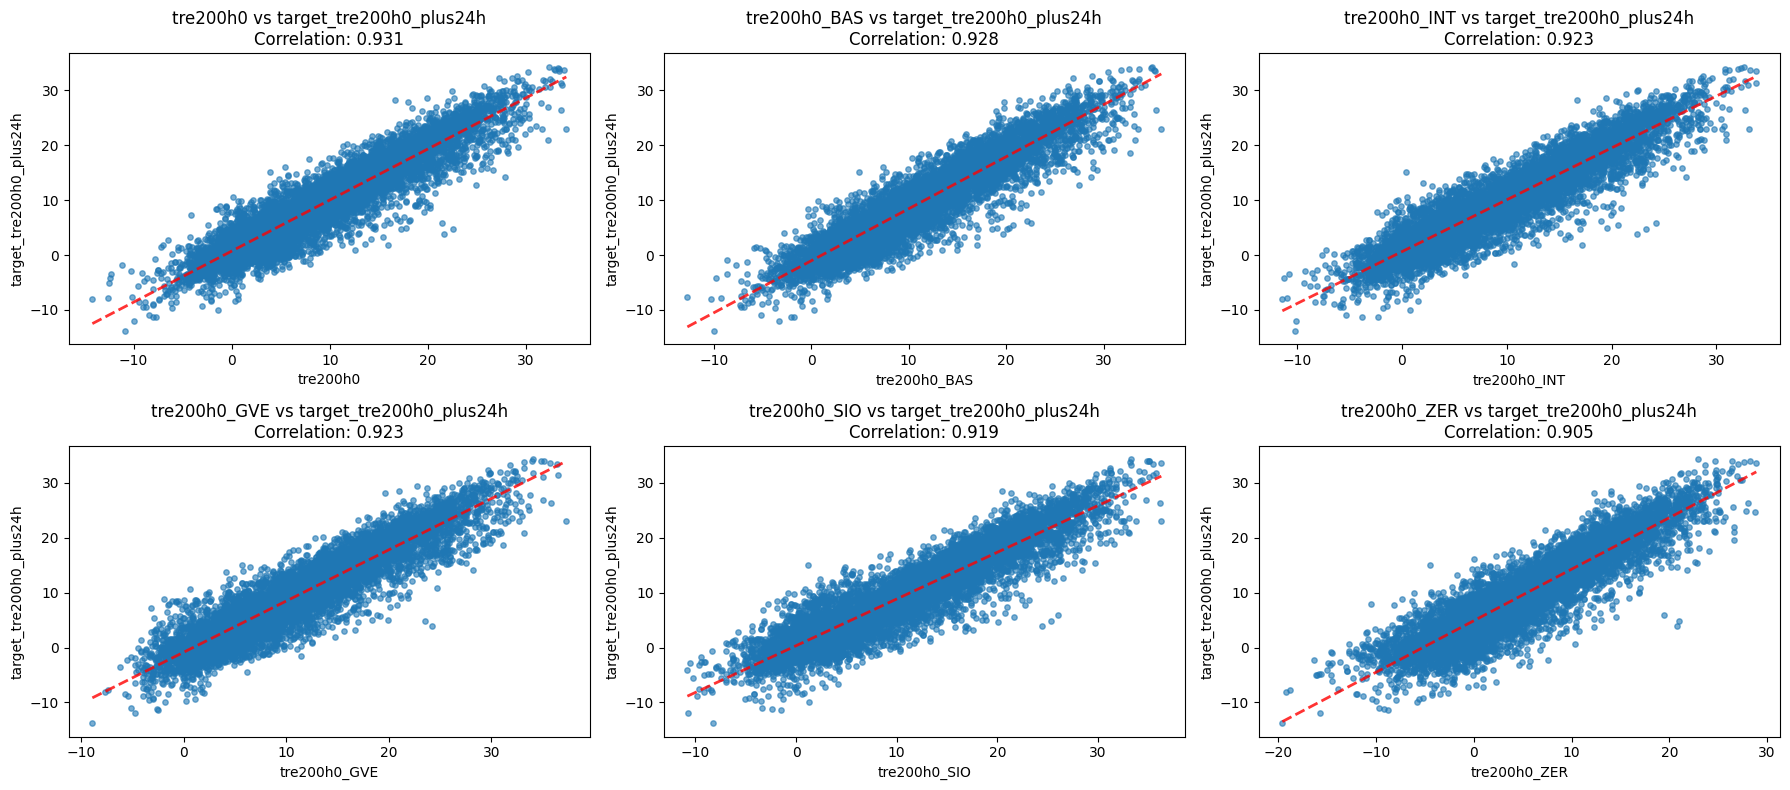

In [115]:
def plot_top_correlations(df, target_col='target_tre200h0_plus24h', k=6,
                          exclude_cols=('hour', 'season',
                                        'target_tre200h0_plus12h',
                                        'target_tre200h0_plus24h',
                                        'target_tre200h0_plus48h')):
    # Select numeric predictors only, excluding specified columns (targets and helpers)
    num_cols = df.select_dtypes(include=np.number).columns  # Get all numeric columns
    pred_cols = [c for c in num_cols if c not in exclude_cols]  # Filter out excluded columns

    # Calculate absolute correlations with the target column and sort them
    corrs = df[pred_cols].corrwith(df[target_col]).abs().sort_values(ascending=False)
    top_feats = corrs.head(k).index.tolist()  # Select the top k features based on correlation

    # Create a grid layout for subplots (2 rows x 3 cols if k=6)
    rows = int(np.ceil(k / 3))  # Calculate the number of rows needed
    cols = 3 if k >= 3 else k  # Set the number of columns
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))  # Create subplots
    axes = np.atleast_1d(axes).flatten()  # Flatten the axes array for easy iteration

    # Plot each of the top features against the target variable
    for ax, col in zip(axes, top_feats):
        # Clean NaN values for plotting
        x = df[col].values  # Predictor values
        y = df[target_col].values  # Target values
        m = ~np.isnan(x) & ~np.isnan(y)  # Boolean mask for non-NaN values
        x, y = x[m], y[m]  # Filter NaN values

        # Create a scatter plot
        ax.scatter(x, y, alpha=0.6, s=15)  # Scatter plot with transparency and size

        # Compute and plot the Ordinary Least Squares (OLS) regression line
        if x.size >= 2:  # Ensure there are enough points for fitting
            z = np.polyfit(x, y, 1)  # Fit a degree-1 polynomial (line)
            p = np.poly1d(z)  # Create a polynomial function from the coefficients
            xx = np.linspace(x.min(), x.max(), 200)  # Create a range for plotting the line
            ax.plot(xx, p(xx), "r--", alpha=0.8, lw=2)  # Plot the regression line

        # Calculate the Pearson correlation coefficient
        r = np.corrcoef(x, y)[0, 1] if x.size > 1 else np.nan  # Calculate correlation
        ax.set_title(f"{col} vs {target_col}\nCorrelation: {r:.3f}")  # Set title
        ax.set_xlabel(col)  # Set x-axis label
        ax.set_ylabel(target_col)  # Set y-axis label

    # Hide any empty axes (if k is not a multiple of 3)
    for ax in axes[len(top_feats):]:
        ax.axis('off')  # Turn off the axes

    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()  # Display the plots

# ---- Use it on your dataframe (choose which version) ----
# df = train_mean_imp  # or train_median_imp, train_drop, or train
plot_top_correlations(train, target_col='target_tre200h0_plus24h', k=6)


# 0. PCA Analysis on Scaled Datasets: Variance Visualization and Summary


--- PCA Variance Plot and Table for: drop_na ---


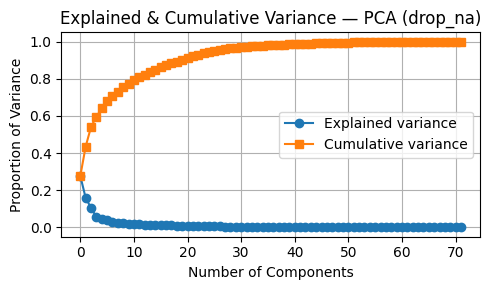

    Component  EigenValue  Variance (%)  Cumulative Variance (%)
34         35      0.1374        0.1908                  97.8202
35         36      0.1193        0.1657                  97.9859
36         37      0.1094        0.1519                  98.1377
37         38      0.1025        0.1424                  98.2801
38         39      0.0892        0.1239                  98.4040
39         40      0.0848        0.1178                  98.5217
40         41      0.0836        0.1162                  98.6379
41         42      0.0729        0.1012                  98.7391
42         43      0.0714        0.0991                  98.8382
43         44      0.0683        0.0949                  98.9331
44         45      0.0675        0.0937                  99.0267
Number of features in PCA: 72
Any targets included?: False

--- PCA Variance Plot and Table for: mean_imputed ---


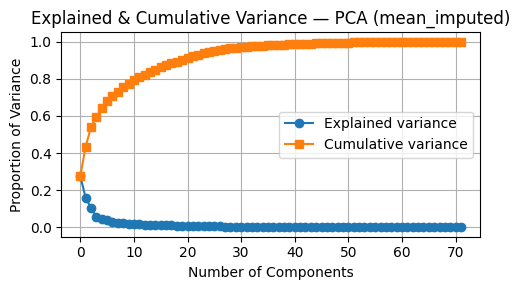

    Component  EigenValue  Variance (%)  Cumulative Variance (%)
34         35      0.1374        0.1908                  97.8202
35         36      0.1193        0.1657                  97.9859
36         37      0.1094        0.1519                  98.1377
37         38      0.1025        0.1424                  98.2801
38         39      0.0892        0.1239                  98.4040
39         40      0.0848        0.1178                  98.5217
40         41      0.0836        0.1162                  98.6379
41         42      0.0729        0.1012                  98.7391
42         43      0.0714        0.0991                  98.8382
43         44      0.0683        0.0949                  98.9331
44         45      0.0675        0.0937                  99.0267
Number of features in PCA: 72
Any targets included?: False

--- PCA Variance Plot and Table for: median_imputed ---


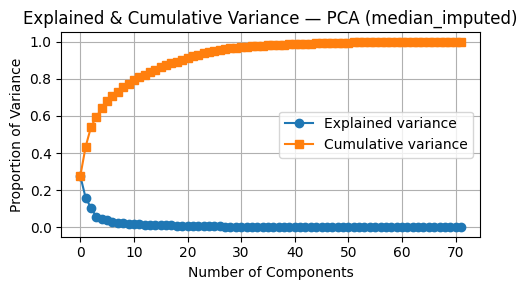

    Component  EigenValue  Variance (%)  Cumulative Variance (%)
34         35      0.1374        0.1908                  97.8202
35         36      0.1193        0.1657                  97.9859
36         37      0.1094        0.1519                  98.1377
37         38      0.1025        0.1424                  98.2801
38         39      0.0892        0.1239                  98.4040
39         40      0.0848        0.1178                  98.5217
40         41      0.0836        0.1162                  98.6379
41         42      0.0729        0.1012                  98.7391
42         43      0.0714        0.0991                  98.8382
43         44      0.0683        0.0949                  98.9331
44         45      0.0675        0.0937                  99.0267
Number of features in PCA: 72
Any targets included?: False


In [116]:
# ============================================
# PCA variance plots + tables for each dataset
# (using the datasets built in Step 1)
# ============================================

# If not already defined:
target_cols = [
    "target_tre200h0_plus12h",
    "target_tre200h0_plus24h",
    "target_tre200h0_plus48h"
]

feature_prefixes = ['fkl010h', 'gre000h0', 'rre150h0', 'prestah0', 'ure200h0', 'tre200h0']

cols_to_scale = [
    c for c in base.columns
    if any(p in c for p in feature_prefixes) and c not in target_cols
]

for label in ['drop_na', 'mean_imputed', 'median_imputed']:
    print(f"\n--- PCA Variance Plot and Table for: {label} ---")

    df = datasets[label].copy()
    X = df[cols_to_scale].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    explained_var = pca.explained_variance_ratio_
    cumulative_var = np.cumsum(explained_var)
    eigenvalues = pca.explained_variance_

    plt.figure(figsize=(5, 3))
    plt.plot(explained_var, marker='o', label='Explained variance')
    plt.plot(cumulative_var, marker='s', label='Cumulative variance')
    plt.title(f'Explained & Cumulative Variance — PCA ({label})')
    plt.xlabel('Number of Components')
    plt.ylabel('Proportion of Variance')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    start_idx = 34  # 35th component
    end_idx = 45    # up to 45th (exclusive)

    summary_df = pd.DataFrame({
        'Component': np.arange(1, len(eigenvalues) + 1),
        'EigenValue': eigenvalues,
        'Variance (%)': explained_var * 100,
        'Cumulative Variance (%)': cumulative_var * 100
    })

    print(summary_df.loc[start_idx:end_idx - 1].round(4))
    print("Number of features in PCA:", len(cols_to_scale))
    print("Any targets included?:", any(t in cols_to_scale for t in target_cols))


explain like in AD3M what eigen values and communalities are¡¡¡

AS the plots and tables suggest, we will keep 37 components

# 0.1 Applying PCA to Scaled Datasets with Sanity Check

In [117]:
#  pca_n_components = 37

# for label in ['drop_na', 'mean_imputed', 'median_imputed']:
    #df_scaled = datasets[label].copy()

    # Apply PCA only on scaled columns
    #pca = PCA(n_components=pca_n_components)
    # X_pca = pca.fit_transform(df_scaled[cols_to_scale])

    # pca_cols = [f'pca_{i+1}' for i in range(pca_n_components)]
    # X_pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=df_scaled.index)

    # Drop scaled columns, keep targets + others
    # df_pca = df_scaled.drop(columns=cols_to_scale)
    # df_pca = pd.concat([df_pca, X_pca_df], axis=1)

    # Ensure targets are included
    # for tgt in target_cols:
        # if tgt not in df_pca.columns and tgt in df_scaled.columns:
            # df_pca[tgt] = df_scaled[tgt]

    #datasets[f"{label}_pca"] = df_pca

# =====================================================
# 4️⃣  Sanity check
# =====================================================
# for name in ['mean_imputed', 'mean_imputed_pca']:
    # print(f"\n{name}:")
    # print(datasets[name].filter(like='target').columns.tolist())

# 2. Model Definitions and Hyperparameter Grids for PCA and Regression Techniques

In [118]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=num_cores
    ),
    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=num_cores
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = xgb.XGBRegressor(
        objective="reg:absoluteerror",   # MAE-compatible
        n_jobs=num_cores,
        random_state=42,
        tree_method="hist"
    )

if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = lgb.LGBMRegressor(
        objective="mae",                 # MAE-compatible
        n_jobs=num_cores,
        random_state=42
    )

In [119]:
# Define model configurations with enhanced hyperparameters
model_configs = {}

# 1. XGBoost (usually best for tabular data)
if XGBOOST_AVAILABLE:
    model_configs['XGBoost'] = {
        'model': xgb.XGBRegressor(
            objective='reg:absoluteerror',  # Optimize for MAE directly
            n_jobs=num_cores,
            random_state=42,
            tree_method='hist'  # Faster training
        ),
        'param_grid': {
            'regressor__n_estimators': [500, 800, 1000],
            'regressor__max_depth': [5, 7, 9],
            'regressor__learning_rate': [0.01, 0.05, 0.1],
            'regressor__subsample': [0.8, 0.9],
            'regressor__colsample_bytree': [0.8, 0.9],
            'regressor__min_child_weight': [1, 3, 5],
            'regressor__gamma': [0, 0.1, 0.2]
        },
        'use_pca': False
    }

# 2. LightGBM (very fast and accurate)
if LIGHTGBM_AVAILABLE:
    model_configs['LightGBM'] = {
        'model': lgb.LGBMRegressor(
            objective='mae',  # Optimize for MAE
            n_jobs=num_cores,
            random_state=42,
            verbose=-1
        ),
        'param_grid': {
            'regressor__n_estimators': [500, 800, 1000],
            'regressor__max_depth': [5, 7, 9, -1],
            'regressor__learning_rate': [0.01, 0.05, 0.1],
            'regressor__num_leaves': [31, 50, 70],
            'regressor__min_child_samples': [20, 30, 50],
            'regressor__subsample': [0.8, 0.9],
            'regressor__colsample_bytree': [0.8, 0.9]
        },
        'use_pca': False
    }

# 3. CatBoost (handles categorical features well, no preprocessing needed)
# if CATBOOST_AVAILABLE:
#     model_configs['CatBoost'] = {
#         'model': cb.CatBoostRegressor(
#             loss_function='MAE',  # Optimize for MAE
#             thread_count=num_cores,
#             random_state=42,
#             verbose=0
#         ),
#         'param_grid': {
#             'regressor__iterations': [500, 800, 1000],
#             'regressor__depth': [5, 7, 9],
#             'regressor__learning_rate': [0.01, 0.05, 0.1],
#             'regressor__l2_leaf_reg': [1, 3, 5]
#         },
#         'use_pca': False
#     }

# 4. Enhanced Random Forest (your current best)
model_configs['Random Forest Enhanced'] = {
    'model': RandomForestRegressor(
        n_jobs=num_cores,
        random_state=42,
        criterion='absolute_error'  # Optimize for MAE
    ),
    'param_grid': {
        'regressor__n_estimators': [300, 500, 700],
        'regressor__max_depth': [15, 20, 25, None],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [1, 2, 4],
        'regressor__max_features': ['sqrt', 'log2', 0.8]
    },
    'use_pca': False
}

# 5. Extra Trees (often performs well with less overfitting)
model_configs['Extra Trees'] = {
    'model': ExtraTreesRegressor(
        n_jobs=num_cores,
        random_state=42,
        criterion='absolute_error'
    ),
    'param_grid': {
        'regressor__n_estimators': [300, 500],
        'regressor__max_depth': [15, 20, None],
        'regressor__min_samples_split': [2, 5],
        'regressor__min_samples_leaf': [1, 2]
    },
    'use_pca': False
}

# 6. Gradient Boosting (enhanced)
model_configs['Gradient Boosting Enhanced'] = {
    'model': GradientBoostingRegressor(
        loss='absolute_error',  # MAE loss
        random_state=42
    ),
    'param_grid': {
        'regressor__n_estimators': [300, 500, 700],
        'regressor__max_depth': [4, 6, 8],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__subsample': [0.8, 0.9],
        'regressor__min_samples_split': [2, 5],
        'regressor__min_samples_leaf': [1, 2]
    },
    'use_pca': False
}

# 7. Ridge Regression (baseline)
model_configs['Ridge Enhanced'] = {
    'model': Ridge(random_state=42),
    'param_grid': {
        'regressor__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
    },
    'use_pca': False
}

print(f"\nConfigured {len(model_configs)} models:")
for name in model_configs.keys():
    print(f"  - {name}")


Configured 6 models:
  - XGBoost
  - LightGBM
  - Random Forest Enhanced
  - Extra Trees
  - Gradient Boosting Enhanced
  - Ridge Enhanced


In [ ]:
# If you keep your existing pca_components list, reuse it. Otherwise define a simple default:
pca_components = [37, 40, 44]

models = {}
param_grids = {}

for name, cfg in model_configs.items():
    # 1) Store the model object
    models[name] = cfg['model']

    # 2) Base hyperparameter grid from your friend's code
    base_grid = cfg.get('param_grid', {})
    use_pca = cfg.get('use_pca', False)

    grids = []

    # --- without PCA ---
    grids.append({
        "preprocessor__num__pca": ["passthrough"],
        **base_grid
    })

    # --- with PCA, only if your friend says use_pca=True ---
    if use_pca:
        grids.append({
            "preprocessor__num__pca": [PCA()],
            "preprocessor__num__pca__n_components": pca_components,
            **base_grid
        })

    param_grids[name] = grids

print("\nModels defined from friend configs:", list(models.keys()))
print("Param grids defined for:", list(param_grids.keys()))



Models defined from friend configs: ['XGBoost', 'LightGBM', 'Random Forest Enhanced', 'Extra Trees', 'Gradient Boosting Enhanced', 'Ridge Enhanced']
Param grids defined for: ['XGBoost', 'LightGBM', 'Random Forest Enhanced', 'Extra Trees', 'Gradient Boosting Enhanced', 'Ridge Enhanced']


# 3. Model Evaluation Function with Optional Hyperparameter Tuning and PCA Detection

In [121]:
def evaluate_model(model, X_train, X_test, y_train, y_test, preprocessor, model_name):
    """
    Fit and evaluate a single model on a given train/test split.

    Steps:
    - Build a Pipeline(preprocessor + regressor)
    - Run GridSearchCV with the corresponding hyperparameter grid (if any),
      using MAE as the scoring metric
    - Compute train/test metrics and return them in a result dict
    """

    start_time = time.time()  # start timer to measure wall-clock training + tuning time

    # 1) Build the full pipeline:
    #    - 'preprocessor' is the ColumnTransformer (numeric + categorical pipelines)
    #    - 'regressor' is the model (RF, GB, SVR, MLP, etc.) passed in as `model`
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model)
    ])

    # 2) Get the hyperparameter grid for this model, if it exists
    #    param_grids is a global dict: {model_name: [list of param grid dicts]}
    param_grid = param_grids.get(model_name, None)

    # 3) If a param grid is defined, run GridSearchCV to tune hyperparameters
    if param_grid is not None and len(param_grid) > 0:
        print(f"   -> Running GridSearchCV for {model_name} (optimising MAE)...")

        grid_search = GridSearchCV(
            estimator=pipeline,                    # full preprocessing + model pipeline
            param_grid=param_grid,                 # list of parameter dictionaries
            scoring="neg_mean_absolute_error",     # IMPORTANT: competition metric (MAE)
            cv=5,                                  # 5-fold cross-validation
            n_jobs=num_cores,                      # use multiple cores in parallel
            refit=True,                            # refit pipeline on full training data with best params
            verbose=0
        )

        # Fit the grid search on the training data
        grid_search.fit(X_train, y_train)

        # Extract the best pipeline (with the best hyperparameters)
        best_pipeline = grid_search.best_estimator_
        best_params = grid_search.best_params_

        # Cross-validated MAE (note: sklearn returns NEGATIVE MAE, so we flip the sign)
        cv_mae_mean = -grid_search.best_score_  # convert from neg-MAE to MAE
        cv_mae_std = grid_search.cv_results_["std_test_score"][grid_search.best_index_]


        # Check whether PCA was actually used in the best configuration
        used_pca = best_params.get("preprocessor__num__pca", "passthrough") != "passthrough"

    else:
        # 4) If no param grid is provided, fit the pipeline with default hyperparameters
        print(f"   -> No param grid for {model_name}. Fitting default pipeline...")

        best_pipeline = pipeline          # just use the pipeline as-is
        best_pipeline.fit(X_train, y_train)

        # Even without a param grid, we can still estimate CV MAE for reporting
        cv_scores = cross_val_score(
            best_pipeline,
            X_train,
            y_train,
            scoring="neg_mean_absolute_error",  # again, MAE as evaluation metric
            cv=5,
            n_jobs=num_cores
        )
        cv_mae_mean = -cv_scores.mean()          # flip sign because scores are negative
        cv_mae_std = cv_scores.std()

        used_pca = False                         # we did not tune PCA here, so assume False
        best_params = None                       # no tuned hyperparameters in this branch

    # 5) Make predictions on train and test sets using the fitted pipeline
    y_train_pred = best_pipeline.predict(X_train)
    y_test_pred = best_pipeline.predict(X_test)

    # 6) Compute metrics on train and test data
    train_mae = mean_absolute_error(y_train, y_train_pred)   # training MAE
    test_mae = mean_absolute_error(y_test, y_test_pred)      # test MAE (main selection metric)

    # Older versions of scikit-learn don't have 'squared' argument in mean_squared_error,
    # so we compute RMSE as sqrt(MSE) manually.
    mse_test = mean_squared_error(y_test, y_test_pred)       # test MSE
    test_rmse = np.sqrt(mse_test)                            # test RMSE

    test_r2 = r2_score(y_test, y_test_pred)                  # test R²

    # 7) Compute total training + tuning time
    training_time = time.time() - start_time

    # 8) Pack all relevant information into a result dictionary
    result = {
        # Meta information
        "model_name": model_name,
        "used_pca": used_pca,                  # whether PCA was used in the best configuration
        "pipeline": best_pipeline,             # fitted Pipeline(preprocessor + best regressor)
        "best_params": best_params,            # best hyperparameters (or None if not tuned),

        # Performance metrics
        "train_mae": train_mae,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_r2": test_r2,

        "cv_mae": cv_mae_mean,                 # cross-validated MAE (mean over folds)
        "cv_std": cv_mae_std,                  # std of cross-validated MAE

        # Timing
        "training_time": training_time         # total wall-clock time in seconds
    }

    return result


# 4. Initialization of Result Storage and Target Configuration for Model Evaluation

In [122]:
# Use datasets dictionary directly (already contains all 6 datasets)
all_results = {}  # Initialize an empty dictionary to store results from model evaluations

# Configuration for the forecasting horizon and target variable
horizon = "24h"  # Define the time horizon for predictions (e.g., 24 hours)
target_col = "target_tre200h0_plus24h"  # Specify the target column to predict during model evaluation


# 5. Modification of Dataset Evaluation Loop to Include Multiple Datasets

Define which datasets to evaluate
datasets_to_run = ['drop_na', 'mean_imputed', 'median_imputed']  # List of datasets for evaluation

Iterate through each dataset in the datasets dictionary
for name, dataset in datasets.items():
    print(f"\n=== Evaluating models on dataset: {name} ===")

    # Check if the current dataset is in the list of datasets to run
    if name not in datasets_to_run:  # If the dataset is not in the specified list
        print(f"Skipping {name} (not in datasets_to_run).")  # Print a message and skip this dataset
        continue  # Continue to the next dataset

    # (Continue with the evaluation process for datasets included in datasets_to_run)


# Run all models on selected imputed dataset, store ALL models + the BEST model

In [ ]:
# Make sure evaluate_model, models, datasets, horizon, target_col, param_grids, num_cores are already defined

# 1) Choose which dataset to run (single dataset)
base_label = "drop_na"           # e.g. "median_imputed", "mean_imputed", "drop_na", ...
name = base_label                # keep a single name variable for consistency

print(f"\n⚙️ Running modelling for single dataset: {name}")

# 2) Global containers to collect fitted pipelines
all_pipelines = {}        # all_pipelines[(name, model_name)] -> fitted Pipeline object

best_model_info = None    # will store dataset name, model name, metrics, pipeline
best_mae = np.inf         # start from +∞ so the first model is always “better”

# 3) Sanity check: dataset must exist in `datasets` dict
if name not in datasets:
    raise ValueError(f"Dataset '{name}' not found in datasets.")

print(f"\n=== Evaluating models on dataset: {name} ===")

# Work on a copy of the dataset to avoid side effects
data_model = datasets[name].copy()
print("Modelling dataset shape:", data_model.shape)
print("Total remaining NAs:", data_model.isna().sum().sum())

# 4) Define predictors and target (same logic as before)
all_predictors = [
    col for col in data_model.columns
    if col not in [
        "target_tre200h0_plus12h",
        "target_tre200h0_plus24h",
        "target_tre200h0_plus48h"
    ]
]

X = data_model[all_predictors].copy()
y = data_model[target_col].copy()   # e.g. "target_tre200h0_plus24h"

# Remove duplicated columns in X (safeguard)
X = X.loc[:, ~X.columns.duplicated()]
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print(f"Selected horizon (target_col): {target_col} | Horizon label: {horizon}")

# 5) Identify numeric vs categorical features for the ColumnTransformer
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", categorical_features)

# 6) Define preprocessing pipelines
impute_strategy = "median" if name == "median_imputed" else "mean"

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy=impute_strategy)),
    ("scaler", StandardScaler()),
    ("pca", "passthrough")
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

# 7) Train–test split (hold-out set for final evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# 8) Loop over all candidate models for this single dataset
results = {}   # store results for this dataset (keyed by model_name)

for model_name, model in models.items():
    print(f"\n🔍 Evaluating {model_name} on '{name}' (imputation type: {base_label})...")

    start = time.time()
    # Your existing evaluate_model: do NOT change its internals
    result = evaluate_model(
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        preprocessor=preprocessor,
        model_name=model_name
    )
    end = time.time()
    result["training_time"] = end - start

    # Save full result for this model
    results[model_name] = result

    # Save fitted pipeline for later reuse (e.g. Kaggle submission)
    all_pipelines[(name, model_name)] = result["pipeline"]

    # Update the global best model by Test MAE
    if result["test_mae"] < best_mae:
        best_mae = result["test_mae"]
        best_model_info = {
            "dataset": name,
            "model_name": model_name,
            "metrics": result,
            "pipeline": result["pipeline"]
        }

    # Verbose metrics
    print(f"Used PCA:       {result.get('used_pca', False)}")
    print(f"MAE (train):    {result['train_mae']:.3f}")
    print(f"MAE (test):     {result['test_mae']:.3f}")
    print(f"RMSE (test):    {result['test_rmse']:.3f}")
    print(f"R² (test):      {result['test_r2']:.3f}")
    print(f"CV MAE:         {result['cv_mae']:.3f} (±{result['cv_std']:.3f})")
    print(f"Training time:  {result['training_time']:.2f} s")

# 9) Store results for this (single) dataset
all_results[name] = results

print("\n✅ Finished evaluating dataset.")
print("Saved datasets in all_results:", list(all_results.keys()))
print("\n📦 Stored pipelines for (dataset, model) pairs:", len(all_pipelines))

print("\n⭐ Best model overall (by Test MAE):")
print("  Dataset:  ", best_model_info["dataset"])
print("  Model:    ", best_model_info["model_name"])
print("  Best MAE: ", best_mae)



⚙️ Running modelling for single dataset: drop_na

=== Evaluating models on dataset: drop_na ===
Modelling dataset shape: (5999, 128)
Total remaining NAs: 0
Shape of X: (5999, 125)
Shape of y: (5999,)
Selected horizon (target_col): target_tre200h0_plus24h | Horizon label: 24h
Numerical features: 125
Categorical features: []
Training set shape: (4799, 125)
Test set shape: (1200, 125)

🔍 Evaluating XGBoost on 'drop_na' (imputation type: drop_na)...
   -> Running GridSearchCV for XGBoost (optimising MAE)...


In [ ]:
print("\nBest model overall (from best_model_info):")
print("  Dataset:      ", best_model_info["dataset"])
print("  Model name:   ", best_model_info["model_name"])
print("  Best Test MAE:", best_mae)

best_metrics = best_model_info["metrics"].copy()
best_metrics.pop("pipeline", None)

print("\nMetrics for best model:")
for k, v in best_metrics.items():
    print(f"  {k}: {v}")

print("\nAttempting to extract feature importances (or coefficients)")

pipeline = best_model_info["pipeline"]

try:
    preprocessor = pipeline.named_steps["preprocessor"]
    regressor = pipeline.named_steps["regressor"]

    # Tree-based models
    if hasattr(regressor, "feature_importances_"):
        importances = regressor.feature_importances_
        feature_names = preprocessor.get_feature_names_out()

        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        print("\nTop 30 most important features (tree-based model):")
        display(importance_df.head(30))

        plt.figure(figsize=(10, 8))
        top_20 = importance_df.head(20)
        plt.barh(range(len(top_20)), top_20["importance"])
        plt.yticks(range(len(top_20)), top_20["feature"])
        plt.gca().invert_yaxis()
        plt.xlabel("Feature importance")
        plt.title("Top 20 features for best model")
        plt.tight_layout()
        plt.show()

    # Linear models
    elif hasattr(regressor, "coef_"):
        coef = regressor.coef_
        if getattr(coef, "ndim", 1) > 1:
            coef = coef.mean(axis=0)

        feature_names = preprocessor.get_feature_names_out()

        coef_df = pd.DataFrame({
            "feature": feature_names,
            "coef": coef,
            "abs_coef": abs(coef)
        }).sort_values("abs_coef", ascending=False)

        print("\nTop 30 features by absolute coefficient (linear model):")
        display(coef_df.head(30))

        plt.figure(figsize=(10, 8))
        top_20 = coef_df.head(20)
        plt.barh(range(len(top_20)), top_20["abs_coef"])
        plt.yticks(range(len(top_20)), top_20["feature"])
        plt.gca().invert_yaxis()
        plt.xlabel("Absolute coefficient")
        plt.title("Top 20 features for best linear model")
        plt.tight_layout()
        plt.show()

    else:
        print("Model does not expose feature_importances_ or coef_. No feature ranking available.")

except Exception as e:
    print(f"Could not extract feature importances: {e}")


# Build the summary DataFrame (one dataset, all models)

In [ ]:
summary_rows = []  # will collect one dict (row) per (dataset, model)

for dataset_name, model_results in all_results.items():
    # model_results is a dict: {model_name: result_dict}
    for model_name, result in model_results.items():
        summary_rows.append({
            # --- Meta info about the run ---
            "Horizon": horizon,           # e.g. "24h"
            "Target_Col": target_col,     # e.g. "target_tre200h0_plus24h"
            "Dataset": dataset_name,      # e.g. "drop_na" or "median_imputed"
            "Used_PCA": result.get("used_pca", False),  # whether PCA was actually used in the best pipeline

            # --- Model identifier ---
            "Model": model_name,          # e.g. "Random Forest", "Ridge", etc.

            # --- Metrics (train / test / CV) ---
            "MAE_Train": result.get("train_mae", np.nan),   # training MAE
            "MAE_Test": result.get("test_mae", np.nan),     # test MAE (main selection metric)
            "RMSE_Test": result.get("test_rmse", np.nan),   # test RMSE
            "R²_Test": result.get("test_r2", np.nan),       # test R²

            "CV_MAE_Mean": result.get("cv_mae", np.nan),    # cross-validated MAE (mean over folds)
            "CV_MAE_Std": result.get("cv_std", np.nan),     # std dev of CV MAE

            # --- Timing ---
            "Training_Time_s": result.get("training_time", np.nan),  # wall-clock training time in seconds
        })

# If nothing was added, all_results is probably empty
if not summary_rows:
    print("⚠️ No results found in all_results. Did you run the evaluation loop?")
else:
    # Convert list of dicts to a DataFrame
    results_df = pd.DataFrame(summary_rows)

    # Sort rows: best first by lowest Test MAE, then by lowest Test RMSE
    results_df = results_df.sort_values(
        by=["MAE_Test", "RMSE_Test"]
    ).reset_index(drop=True)

    # Round numeric columns for nicer, compact display
    results_df = results_df.round(3)

    # Display in notebook (fallback to print if display is not defined)
    try:
        display(results_df)
    except NameError:
        print(results_df)


In [ ]:
# ==========================================================
# 1. RE-SHOW SUMMARY (OPTIONAL, YOU ALREADY BUILT results_df)
# ==========================================================
print("\nSummary of all models and datasets (sorted by Test MAE and RMSE):")
try:
    display(results_df)
except NameError:
    print(results_df)

# ==========================================================
# 2. PRINT DETAILED INFO FOR THE BEST MODEL
# ==========================================================
print("\nBest model overall (from best_model_info):")
print("  Horizon:     ", horizon)
print("  Target col:  ", target_col)
print("  Dataset:     ", best_model_info["dataset"])
print("  Model name:  ", best_model_info["model_name"])
print("  Best Test MAE:", best_mae)

best_metrics = best_model_info["metrics"].copy()
# Remove the pipeline object from the printed metrics to keep it readable
best_metrics.pop("pipeline", None)

print("\nMetrics for best model:")
for k, v in best_metrics.items():
    print(f"  {k}: {v}")

# ==========================================================
# 3. FEATURE IMPORTANCES / COEFFICIENTS FOR BEST MODEL
# ==========================================================
print("\nAttempting to extract feature importances (or coefficients)")

pipeline = best_model_info["pipeline"]

try:
    preprocessor = pipeline.named_steps["preprocessor"]
    regressor = pipeline.named_steps["regressor"]

    # Try tree-based feature_importances_
    if hasattr(regressor, "feature_importances_"):
        importances = regressor.feature_importances_
        feature_names = preprocessor.get_feature_names_out()

        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        print("\nTop 30 most important features (tree-based model):")
        try:
            display(importance_df.head(30))
        except NameError:
            print(importance_df.head(30))

        # Plot top 20
        plt.figure(figsize=(10, 8))
        top_20 = importance_df.head(20)
        plt.barh(range(len(top_20)), top_20["importance"])
        plt.yticks(range(len(top_20)), top_20["feature"])
        plt.gca().invert_yaxis()
        plt.xlabel("Feature importance")
        plt.title("Top 20 features for best model")
        plt.tight_layout()
        plt.show()

    # If no feature_importances_, try linear model coefficients
    elif hasattr(regressor, "coef_"):
        coef = regressor.coef_
        # Handle multi-output or 2D coef_
        if getattr(coef, "ndim", 1) > 1:
            # Use mean of absolute coefficients across outputs
            coef = coef.mean(axis=0)

        feature_names = preprocessor.get_feature_names_out()

        coef_df = pd.DataFrame({
            "feature": feature_names,
            "coef": coef,
            "abs_coef": abs(coef)
        }).sort_values("abs_coef", ascending=False)

        print("\nTop 30 features by absolute coefficient (linear model):")
        try:
            display(coef_df.head(30))
        except NameError:
            print(coef_df.head(30))

        # Plot top 20
        plt.figure(figsize=(10, 8))
        top_20 = coef_df.head(20)
        plt.barh(range(len(top_20)), top_20["abs_coef"])
        plt.yticks(range(len(top_20)), top_20["feature"])
        plt.gca().invert_yaxis()
        plt.xlabel("Absolute coefficient")
        plt.title("Top 20 features for best linear model")
        plt.tight_layout()
        plt.show()

    else:
        print("Model does not expose feature_importances_ or coef_. No feature ranking available.")

except Exception as e:
    print(f"Could not extract feature importances: {e}")


# Inspect predictions of the best model (selected by lowest test MAE)

In [ ]:
# --- 0) Pick the best model (lowest Test MAE) from all_results ---

# Instead of recomputing:
best_dataset_name = best_model_info["dataset"]
best_model_name = best_model_info["model_name"]
best_entry = best_model_info["metrics"]      # same dict you stored before
best_mae = best_model_info["metrics"]["test_mae"]
best_pipeline = best_model_info["pipeline"]

print(f"Best dataset (by MAE): {best_dataset_name}")
print(f"Best model (by MAE): {best_model_name}")
print(f"Best MAE (test): {best_mae:.3f}")

# --- 1) Recreate X, y and the test set for that dataset ---

# List of all possible target columns, so we can exclude them from predictors
targets = [
    "target_tre200h0_plus12h",
    "target_tre200h0_plus24h",
    "target_tre200h0_plus48h"
]

# Recover the dataset that produced the best model
best_data = datasets[best_dataset_name].copy()

# Same predictors logic as in the training loop: drop all target columns
all_predictors = [
    col for col in best_data.columns
    if col not in targets
]

# Features and target
X = best_data[all_predictors].copy()
y = best_data[target_col].copy()   # same horizon as used in training (e.g. target_tre200h0_plus24h)

# Drop rows with NaN in the target (same cleaning logic as training loop)
mask = ~y.isna()            # keep only rows where y is not NaN
X = X.loc[mask].copy()
y = y.loc[mask].copy()

# Remove duplicated columns in X, just like you did before training
X = X.loc[:, ~X.columns.duplicated()]

# Re-create the SAME train–test split as during training (same random_state!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# --- 2) Use the best pipeline to predict on this internal test set ---

best_pipeline = best_entry["pipeline"]  # fitted Pipeline(preprocessor + model) from evaluate_model

# Generate predictions on the hold-out test set
y_pred = best_pipeline.predict(X_test)

# --- 3) Build an inspection DataFrame for detailed error analysis ---

inspect_df = pd.DataFrame({
    "y_true": y_test.values,   # ground truth
    "y_pred": y_pred           # model predictions
})

# Error = prediction - truth
inspect_df["error"] = inspect_df["y_pred"] - inspect_df["y_true"]
inspect_df["abs_error"] = inspect_df["error"].abs()  # absolute error for ranking

# First few predictions vs. truth (quick sanity check)
display(inspect_df.head(10))

# Worst predictions (largest absolute error) – where the model struggles most
display(inspect_df.sort_values("abs_error", ascending=False).head(5))


In [ ]:
def add_cyclical_features(df):
    """
    Add cyclical encodings for 'hour' (and optionally 'season').
    """
    df = df.copy()

    # 1) Encode hour (0–23) → period = 24
    if "hour" in df.columns and "hour_sin" not in df.columns:
        df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
        df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
        df.drop(columns=["hour"], inplace=True)

    # 2) Encode season (object) as 4-step cycle (OPTIONAL – only if your labels fit)
    if "season" in df.columns and "season_sin" not in df.columns:
        # adjust these strings if your dataset uses something else
        season_order = ["winter", "spring", "summer", "autumn"]
        season_to_num = {s: i for i, s in enumerate(season_order)}

        season_str = df["season"].astype(str).str.lower()
        df["season_num"] = season_str.map(season_to_num)

        df["season_sin"] = np.sin(2 * np.pi * df["season_num"] / 4)
        df["season_cos"] = np.cos(2 * np.pi * df["season_num"] / 4)

        df.drop(columns=["season", "season_num"], inplace=True)

    return df

In [ ]:
# Import test
test = pd.read_csv("ML_WP_data/test.csv")

# Cyclical features
test = add_cyclical_features(test)

# Advanced features
test_features = create_advanced_features(test)

# Build Kaggle submission using best model (by Test MAE)

In [ ]:
# 1) Safety check: we must have found a best model in the evaluation loop
if best_model_info is None:
    raise ValueError("No best model found. Run the evaluation loop first.")

# Extract best model information
best_dataset_name = best_model_info["dataset"]      # e.g. "drop_na"
best_model_name = best_model_info["model_name"]     # e.g. "Random Forest"
best_pipeline = best_model_info["pipeline"]         # fitted Pipeline(preprocessor + regressor)
best_metrics = best_model_info["metrics"]           # dict with MAE, RMSE, R², etc.

print("\nBest overall model (by Test MAE on hold-out set):")
print(f"  Dataset: {best_dataset_name}")
print(f"  Model:   {best_model_name}")
print(f"  Test MAE on hold-out set: {best_metrics['test_mae']:.3f}")

# 2) Rebuild the list of predictors exactly as during training

# Target columns to exclude from the feature set
targets = [
    "target_tre200h0_plus12h",
    "target_tre200h0_plus24h",
    "target_tre200h0_plus48h"
]

# Retrieve the training dataset variant that was used for this best model
best_dataset = datasets[best_dataset_name].copy()

# Predictors = all columns except the targets
all_predictors = [
    col for col in best_dataset.columns
    if col not in targets
]

print("\nNumber of predictors used in training:", len(all_predictors))

# 3) Prepare the Kaggle test set with the SAME feature engineering

# At this point you should already have something like:
#   test = pd.read_csv("ML_WP_data/test.csv")
#   test = add_cyclical_features(test)
# in a previous cell.
# If NOT, uncomment the next two lines:
# test = pd.read_csv("ML_WP_data/test.csv")
# test = add_cyclical_features(test)

test_features = test.copy()  # work on a copy, keep original 'test' intact

# 4) Align predictors between training and Kaggle test

# Keep only those predictors that actually exist in the Kaggle test features
available_predictors = [c for c in all_predictors if c in test_features.columns]
missing_cols = set(all_predictors) - set(available_predictors)

if missing_cols:
    # This warns you if some training columns are missing in the Kaggle test set.
    # They will be ignored for prediction.
    print(
        "Warning: these training columns are missing in the Kaggle test set "
        "and will be ignored:\n",
        missing_cols
    )

print("Number of predictors available in Kaggle test:", len(available_predictors))

# Final feature matrix for Kaggle predictions
X_kaggle = test_features[available_predictors].copy()
print("Shape of X_kaggle:", X_kaggle.shape)

# 5) Predict on Kaggle test set using the best fitted pipeline

# No additional preprocessing here:
# best_pipeline already contains:
#   - the ColumnTransformer (imputers, scaler/encoder, PCA or passthrough)
#   - the best regressor with tuned hyperparameters
y_pred_24 = best_pipeline.predict(X_kaggle)   # predictions for target_tre200h0_plus24h

# 6) Build the Kaggle submission DataFrame

submission = pd.DataFrame({
    "Id": test_features["Id"],                  # Id column from Kaggle test
    "target_tre200h0_plus24h": y_pred_24        # predicted 24h target
})

# Check format (competition expects 3247 rows and 2 columns with header)
print("\nSubmission shape:", submission.shape)
print("Submission columns:", submission.columns.tolist())

# 7) Save submission to CSV with a date-stamped filename

day = date.today().strftime("%Y%m%d")
filename = f"weather_report_submission_{day}.csv"

submission.to_csv(filename, index=False, encoding="utf-8")

print(f"\nSaved Kaggle submission as: {filename}")
print(
    f"Best model used: {best_model_name} | "
    f"Dataset: {best_dataset_name} | "
    f"Test MAE (hold-out): {best_metrics['test_mae']:.3f}"
)

# Quick preview of the first few rows
display(submission.head())

In [ ]:
print(submission.shape)
print(submission.columns.tolist())


In [ ]:
print("Training target stats (y):")
print(datasets["drop_na"][target_col].describe())

print("\nKaggle predictions stats:")
print(pd.Series(y_pred_24).describe())
